In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/fwo_models


In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
from scipy.spatial import distance
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load dims and raw data

## dim `meals`

In [4]:
dim_meals = pl.read_parquet("data/processed/phase_4/dim_meals.parquet")
dim_meals.head()

meal_id,meal_type,schoolyear,restaurant,attributes,aliases
i64,str,str,list[str],list[str],list[str]
9017,"""vegan""","""24-25""","[""che"", ""exa"", ""vik""]","[""vegan-miscellaneous"", ""kela""]","[""""Butter"" härkäpapua & pähkinää""]"
7201,"""vegan""","""23-24""",null,[],"[""2023 Härkäpu-sienilasagnette""]"
9032,"""vegan""","""23-24""",null,[],"[""Appelisiini-luomukikhernecurrya""]"
9102,"""vegan""","""23-24""",null,[],"[""Artisokkavugetteja & tuoretomaattisalsaa""]"
7010,"""vegetarian""","""24-25""","[""che"", ""exa"", ""vik""]",[],"[""Aurajuusto-pinaattilasagnette"", ""Aurajuusto-pinaattilasagnettea""]"


## dim `meal_names`

In [ ]:
dim_meal_names = (
    dim_meals
    .select(
        'meal_id',
        pl.col('aliases').alias('meal')
    )
    .explode('meal')
)
dim_meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


## dim `meal_name_embds`

In [6]:
dim_meal_embds = pl.read_parquet("data/inter/meal_names_embds.parquet")

dim_meal_embds.head()

meal_id,name,embedding
i64,str,list[f64]
9017,"""""Butter"" härkäpapua & pähkinää""","[0.009898, -0.026522, … -0.002193]"
7201,"""2023 Härkäpu-sienilasagnette""","[0.056879, -0.003364, … 0.037541]"
9032,"""Appelisiini-luomukikhernecurry…","[-0.001003, 0.024548, … 0.020614]"
9102,"""Artisokkavugetteja & tuoretoma…","[0.093415, 0.032748, … 0.028103]"
7010,"""Aurajuusto-pinaattilasagnette""","[0.011746, -0.038603, … 0.036116]"


## dim `opentime`

In [7]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


In [8]:
dim_meal_embds = dim_meal_embds.drop('name')

meal_embds = dim_meal_embds.join(dim_meal_embds, how='cross')

embds_1 = meal_embds.get_column('embedding').to_numpy()
embds_2 = meal_embds.get_column('embedding_right').to_numpy()
dist = [distance.cosine(e1, e2) for e1, e2 in zip(embds_1, embds_2)]

meal_embds = meal_embds.with_columns(pl.Series(dist).alias('dist')).drop('embedding', 'embedding_right')

meal_embds.head()

meal_id,meal_id_right,dist
i64,i64,f64
9017,9017,0.0
9017,7201,0.648372
9017,9032,0.516134
9017,9102,0.472851
9017,7010,0.445466


## raw POS

In [9]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)
pos.head()

column_1,column_2,column_3,column_4,column_5,column_6,column_7
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


In [10]:
# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(dim_meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
pos = (
    pos
    .join(
        dim_meals.select('meal_id', 'meal_type'),
        on='meal_id',
        how='left'
    )
)



# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))




pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type
str,date,i64,i64,f64,str
"""phy""",2023-09-08,3012,8,0.693333,"""vegan"""
"""phy""",2023-04-17,90000022,1,0.0,"""chicken"""
"""che""",2023-11-06,6088,18,0.611111,"""vegan"""
"""phy""",2023-09-20,5379,3,0.4,"""meat"""
"""exa""",2024-01-24,90000143,1,0.0,"""meat"""


# Approach 1: Apply TargetEncoding to all meals

## Encode

In [12]:
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)


# Encode meal_id
enc_meal_id = TargetEncoder(target_type='continuous')
enc_meal_id.fit(pos_train.select('meal_id'), pos_train.get_column('pcs'))
pos = pos.with_columns(
    pl.Series('meal_id_enc', values=enc_meal_id.transform(pos.select('meal_id'))).arr.first(),
)



# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos.select('restaurant'))
pos = pos.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos.select('restaurant'))).arr.first().cast(pl.Int32),
)



# Encode meal_type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos.select('meal_type'))
pos = pos.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos.select('meal_type'))).arr.first().cast(pl.Int32),
)



# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Add flag to track records are of old/new meals
meals_old = pos_train.select(pl.col('meal_id').unique()).with_columns(pl.lit(False).alias('is_new'))
pos = pos.join(meals_old, on='meal_id', how='left').with_columns(pl.col('is_new').fill_null(True))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_enc,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool
"""exa""",2023-11-09,9500118,25,0.65,"""vegetarian""",24.557717,1,4,-0.433884,-0.900969,0.968077,-0.250653,-0.5,0.866025,false
"""phy""",2023-08-30,1449,7,0.54,"""meat""",9.441296,2,2,0.433884,-0.900969,-0.201299,0.97953,-0.866025,-0.5,false
"""che""",2024-07-05,7007,131,0.748148,"""vegan""",111.043658,0,3,-0.974928,-0.222521,0.848644,0.528964,-0.5,-0.866025,false
"""exa""",2024-09-12,9500104,52,0.938889,"""vegan""",26.695561,1,3,-0.433884,-0.900969,0.651372,-0.758758,-1.0,-1.8370e-16,false
"""che""",2023-02-22,6542,129,0.962963,"""fish""",65.586075,0,1,0.433884,-0.900969,-0.968077,-0.250653,0.866025,0.5,false


## Train

In [13]:
cols_X = [
    'meal_type_enc',
    'restaurant_enc',

    'meal_id_enc', 
    'serving_percent',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'meal_type_enc',
    'restaurant_enc',
]


pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_enc,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool
"""exa""",2023-11-09,9500118,25,0.65,"""vegetarian""",24.557717,1,4,-0.433884,-0.900969,0.968077,-0.250653,-0.5,0.866025,false
"""phy""",2023-08-30,1449,7,0.54,"""meat""",9.441296,2,2,0.433884,-0.900969,-0.201299,0.97953,-0.866025,-0.5,false
"""che""",2024-07-05,7007,131,0.748148,"""vegan""",111.043658,0,3,-0.974928,-0.222521,0.848644,0.528964,-0.5,-0.866025,false
"""che""",2023-02-22,6542,129,0.962963,"""fish""",65.586075,0,1,0.433884,-0.900969,-0.968077,-0.250653,0.866025,0.5,false
"""vik""",2023-12-12,9500098,1,0.0,"""fish""",132.652778,3,1,0.974928,-0.222521,0.651372,-0.758758,-2.4493e-16,1.0,false


In [14]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


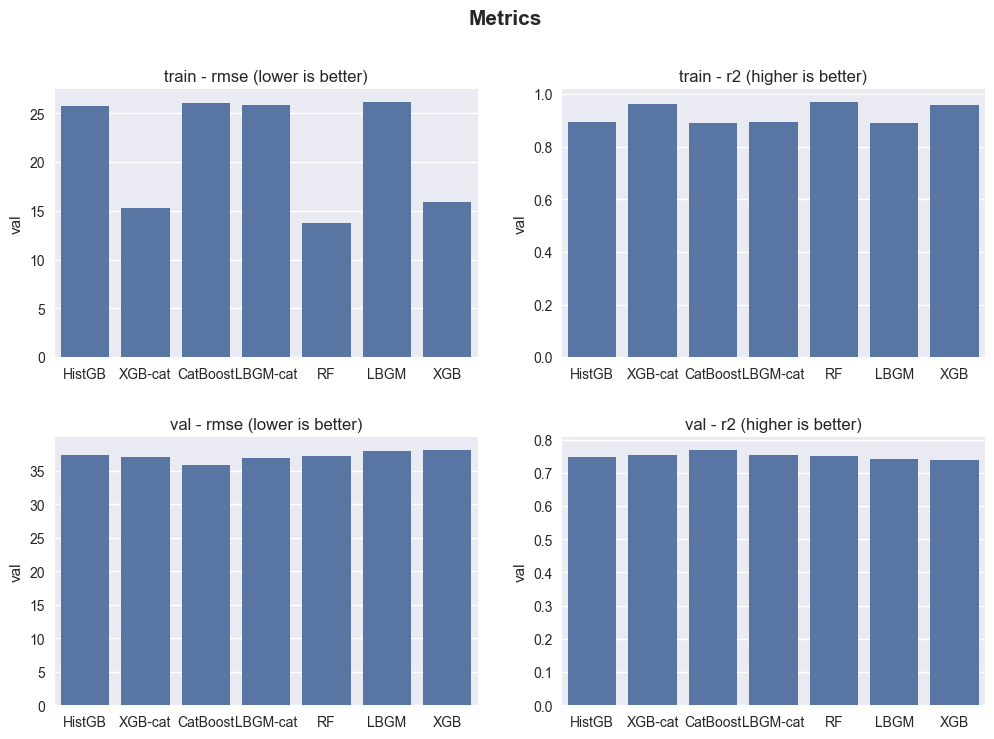

In [15]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split.select(cols_X).to_pandas()
    tgt = split.get_column(col_y).to_pandas()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    # split = (
    #     split
    #     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
    #     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
    #     .reset_index()
    # )
    
    
    rmse = root_mean_squared_error(tgt, pcs_pred).item()
    r2 = r2_score(tgt, pcs_pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

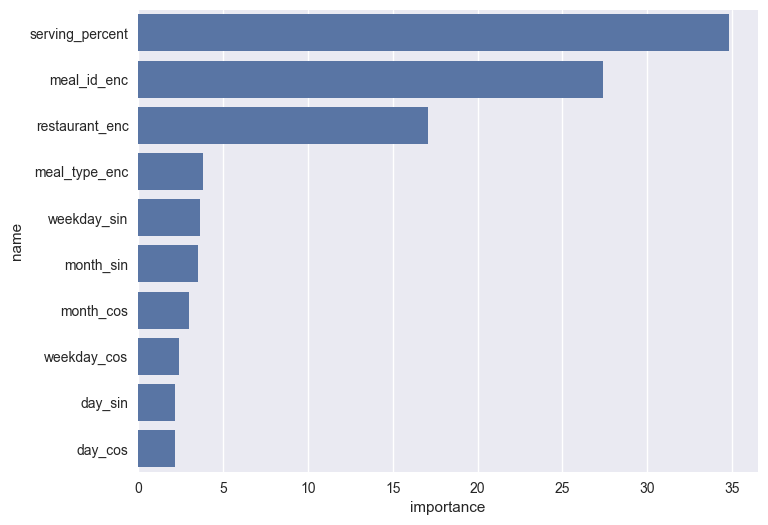

In [16]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['CatBoost']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Separately analyze results of old and new meals

In [17]:
model = models['CatBoost']

In [18]:
X = pos_val.select(cols_X).to_pandas()
tgt = pos_val.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
pos_val = pos_val.select(
    'restaurant', 'date', 'meal_id', 'pcs', 'serving_percent', 'is_new',
    pl.Series(pcs_pred).alias('pcs_pred')
)

pos_val.head()

restaurant,date,meal_id,pcs,serving_percent,is_new,pcs_pred
str,date,i64,i64,f64,bool,f64
"""exa""",2024-09-12,9500104,52,0.938889,false,43.727687
"""vik""",2024-10-29,1021,1,0.0,false,8.952565
"""che""",2024-10-10,8987,14,0.22963,false,9.881742
"""vik""",2024-10-15,6121,30,0.680952,false,25.61029
"""exa""",2024-09-24,9500106,239,1.022222,false,154.387833


In [19]:
split = pos_val.filter(pl.col('is_new'))
r2 = r2_score(split.get_column('pcs'), split.get_column('pcs_pred'))
rmse = root_mean_squared_error(split.get_column('pcs'), split.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 45.8773
r2  : 0.4601


In [20]:
split = pos_val.filter(~pl.col('is_new'))
r2 = r2_score(split.get_column('pcs'), split.get_column('pcs_pred'))
rmse = root_mean_squared_error(split.get_column('pcs'), split.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 34.6994
r2  : 0.7866


# Approach 2: Refer every meals to top K highest sales meals per restaurant and meal_type

In [16]:
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)

In [12]:
K = 5
topK = (
    pos_train
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').sum())
    .with_columns(
        pl.col('pcs').rank(descending=True).over('restaurant', 'meal_type').alias('rank')
    )
    .filter(pl.col('rank') <= K)
    .drop('rank', 'pcs')
)


pcs_mean = (
    pos_train
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').mean().alias('pcs_mean'))
)
topK = (
    topK
    .join(pcs_mean, on=['restaurant', 'meal_type', 'meal_id'], how='left')
)

topK.head()

restaurant,meal_type,meal_id,pcs_mean
str,str,i64,f64
"""exa""","""vegetarian""",819,64.2
"""exa""","""chicken""",90000010,128.153846
"""che""","""vegetarian""",7010,142.0
"""vik""","""meat""",1011,27.121495
"""che""","""chicken""",90000136,162.92


In [13]:
meal_embds = meal_embds.join(
    topK.select(pl.col('meal_id').unique()),
    left_on='meal_id_right',
    right_on='meal_id',
    how='inner'
)

meal_embds.head()

meal_id,meal_id_right,dist
i64,i64,f64
9017,7010,0.445466
9017,1288,0.427253
9017,1289,0.439605
9017,7006,0.492978
9017,6945,0.312643


In [14]:
pos = (
    pos
    .join(topK, on=['restaurant', 'meal_type'], how='left')
    .join(meal_embds, on=['meal_id', 'meal_id_right'], how='left')
)

pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist
str,date,i64,i64,f64,str,i64,f64,f64
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",90000136,162.92,0.479389
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",6930,154.647887,0.644971
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",90000112,204.75,0.800134
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",1288,176.25,0.211532
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",1289,214.142857,0.0


## Encode

In [15]:
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)



# Encode restaurant
dim_restaurant2id = pl.DataFrame([
    {"restaurant": "phy", 'restaurant_enc': 0},
    {"restaurant": "che", 'restaurant_enc': 1},
    {"restaurant": "exa", 'restaurant_enc': 2},
    {"restaurant": "vik", 'restaurant_enc': 3},
])
pos = (
    pos
    .join(dim_restaurant2id, on='restaurant')
)


# Encode meal_type
dim_mealtype2id = pl.DataFrame([
    {"meal_type": "meat", 'meal_type_enc': 0},
    {"meal_type": "vegetarian", 'meal_type_enc': 1},
    {"meal_type": "chicken", 'meal_type_enc': 2},
    {"meal_type": "fish", 'meal_type_enc': 3},
    {"meal_type": "vegan", 'meal_type_enc': 4},
])
pos = (
    pos
    .join(dim_mealtype2id, on='meal_type')
)


# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Add flag to track records are of old/new meals
meals_old = pos_train.select(pl.col('meal_id').unique()).with_columns(pl.lit(False).alias('is_new'))
pos = pos.join(meals_old, on='meal_id', how='left').with_columns(pl.col('is_new').fill_null(True))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,bool
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",90000136,162.92,0.479389,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",6930,154.647887,0.644971,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",90000112,204.75,0.800134,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",1288,176.25,0.211532,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",1289,214.142857,0.0,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false


## Train

In [16]:
cols_X = [
    'meal_id_right',
    'pcs_mean',
    'dist',
    'meal_type_enc',
    'restaurant_enc',
    'serving_percent',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'meal_id_right',
    'meal_type_enc',
    'restaurant_enc',
]


pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,bool
"""phy""",2023-09-08,3012,8,0.693333,"""vegan""",3524,9.786517,0.586522,0,4,-0.974928,-0.222521,0.998717,-0.050649,-1.0,-1.8370e-16,false
"""phy""",2023-09-08,3012,8,0.693333,"""vegan""",6096,14.300493,0.424695,0,4,-0.974928,-0.222521,0.998717,-0.050649,-1.0,-1.8370e-16,false
"""phy""",2023-09-08,3012,8,0.693333,"""vegan""",3012,6.584112,0.0,0,4,-0.974928,-0.222521,0.998717,-0.050649,-1.0,-1.8370e-16,false
"""phy""",2023-09-08,3012,8,0.693333,"""vegan""",6353,7.591463,0.361159,0,4,-0.974928,-0.222521,0.998717,-0.050649,-1.0,-1.8370e-16,false
"""phy""",2023-09-08,3012,8,0.693333,"""vegan""",6137,13.943894,0.539448,0,4,-0.974928,-0.222521,0.998717,-0.050649,-1.0,-1.8370e-16,false


In [17]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0, num_leaves=100), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


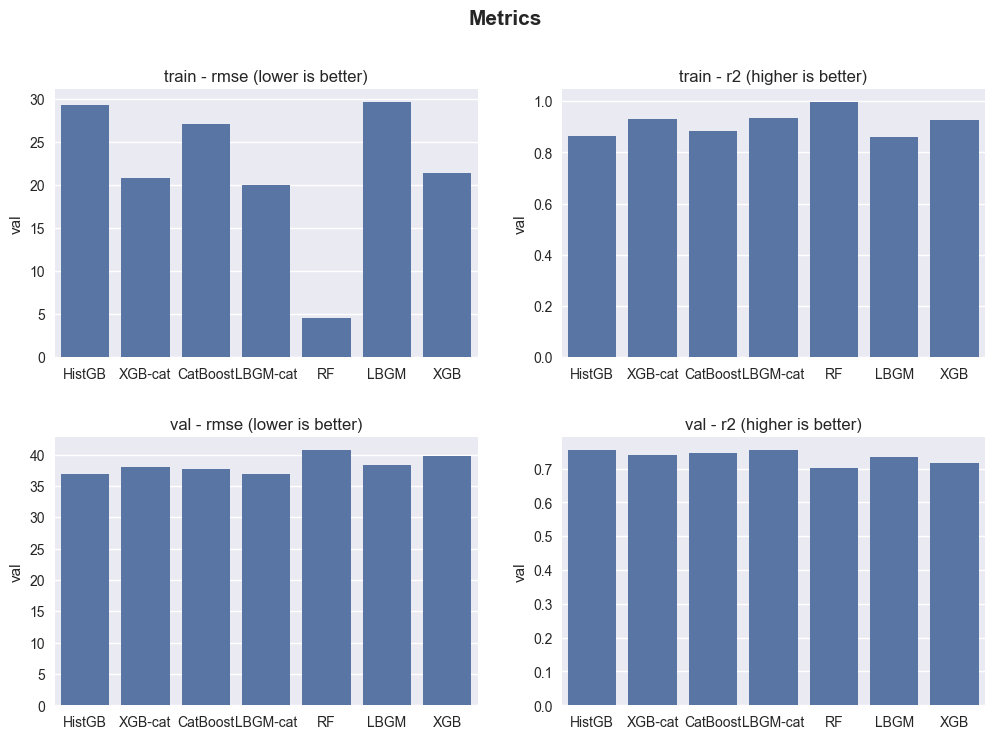

In [18]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    split = split.clone()

    X = split.select(cols_X).to_pandas()
    

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
    split = (
        split
        .group_by(['date', 'restaurant', 'meal_id', 'meal_type'])
        .agg(
            pl.col('pcs').mean(),
            pl.col('pcs_pred').mean(),
        )
    )
    tgt = split.get_column('pcs').to_pandas()
    pred = split.get_column('pcs_pred').to_pandas()
    
    
    rmse = root_mean_squared_error(tgt, pred).item()
    r2 = r2_score(tgt, pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

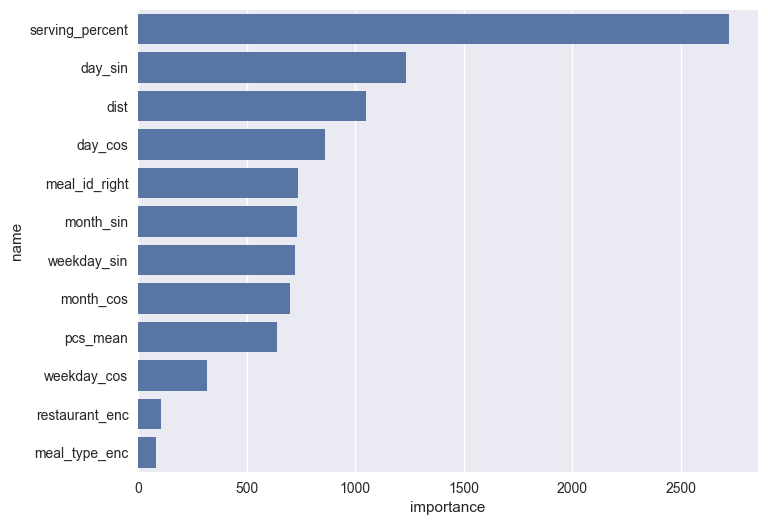

In [19]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['LBGM-cat']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Separately analyze results of old and new meals

In [20]:
model = models['LBGM-cat']

In [21]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

split.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new,pcs_pred
str,date,i64,i64,f64,str,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,bool,f64
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",90000136,162.92,0.479389,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false,305.245206
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",6930,154.647887,0.644971,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false,296.370196
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",90000112,204.75,0.800134,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false,301.339044
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",1288,176.25,0.211532,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false,305.897311
"""che""",2024-09-04,1289,382,0.988889,"""chicken""",1289,214.142857,0.0,1,2,0.433884,-0.900969,0.724793,0.688967,-1.0,-1.8370e-16,false,308.932935


In [22]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
split = (
    split
    .group_by(['date', 'restaurant', 'meal_id', 'meal_type', 'serving_percent', 'is_new'])
    .agg(
        pl.col('pcs').mean(),
        pl.col('pcs_pred').mean(),
    )
)

split.head()

date,restaurant,meal_id,meal_type,serving_percent,is_new,pcs,pcs_pred
date,str,i64,str,f64,bool,f64,f64
2024-10-29,"""che""",1317,"""meat""",0.151852,false,16.0,19.108181
2024-09-09,"""phy""",1512,"""vegetarian""",1.08,false,47.0,29.610544
2024-10-17,"""vik""",1289,"""chicken""",0.928571,false,81.0,70.559321
2024-10-10,"""phy""",1512,"""vegetarian""",1.133333,false,41.0,29.385328
2024-09-13,"""exa""",9037,"""chicken""",0.983333,true,119.0,137.682926


In [23]:
split_new = split.filter(pl.col('is_new'))
r2 = r2_score(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 42.5757
r2  : 0.5350


In [24]:
split_old = split.filter(~pl.col('is_new'))
r2 = r2_score(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 36.3473
r2  : 0.7658


# Create final for inference

## Train model again with entire data

In [11]:
K = 5
topK = (
    pos
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').sum())
    .with_columns(
        pl.col('pcs').rank(descending=True).over('restaurant', 'meal_type').alias('rank')
    )
    .filter(pl.col('rank') <= K)
    .drop('rank', 'pcs')
)


pcs_mean = (
    pos
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').mean().alias('pcs_mean'))
)
topK = (
    topK
    .join(pcs_mean, on=['restaurant', 'meal_type', 'meal_id'], how='left')
)

topK.head()

restaurant,meal_type,meal_id,pcs_mean
str,str,i64,f64
"""vik""","""vegan""",6088,64.608696
"""vik""","""vegan""",6673,58.461538
"""vik""","""fish""",90000081,73.052632
"""che""","""chicken""",90000112,204.75
"""exa""","""chicken""",90000010,135.866667


In [17]:
pos = pl.concat(raw)

# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(dim_meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
pos = (
    pos
    .join(
        dim_meals.select('meal_id', 'meal_type'),
        on='meal_id',
        how='left'
    )
)




# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))



# Get top K meals for each row
pos = (
    pos
    .join(topK, on=['restaurant', 'meal_type'], how='left')
    .join(meal_embds, on=['meal_id', 'meal_id_right'], how='left')
)


# Encode restaurant
# Encode restaurant
dim_restaurant2id = pl.DataFrame([
    {"restaurant": "phy", 'restaurant_enc': 0},
    {"restaurant": "che", 'restaurant_enc': 1},
    {"restaurant": "exa", 'restaurant_enc': 2},
    {"restaurant": "vik", 'restaurant_enc': 3},
])
pos = (
    pos
    .join(dim_restaurant2id, on='restaurant')
)


# Encode meal_type
dim_mealtype2id = pl.DataFrame([
    {"meal_type": "meat", 'meal_type_enc': 0},
    {"meal_type": "vegetarian", 'meal_type_enc': 1},
    {"meal_type": "chicken", 'meal_type_enc': 2},
    {"meal_type": "fish", 'meal_type_enc': 3},
    {"meal_type": "vegan", 'meal_type_enc': 4},
])
pos = (
    pos
    .join(dim_mealtype2id, on='meal_type')
)



# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
str,date,i64,i64,f64,str,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64
"""exa""",2023-01-25,90000074,16,0.927778,"""fish""",90000038,115.428571,0.566855,2,3,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
"""exa""",2023-01-25,90000074,16,0.927778,"""fish""",90000124,125.25,0.5603,2,3,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
"""exa""",2023-01-25,90000074,16,0.927778,"""fish""",90000069,79.92,0.594011,2,3,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
"""exa""",2023-01-25,90000074,16,0.927778,"""fish""",90000074,57.789474,0.0,2,3,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
"""exa""",2023-01-25,90000074,16,0.927778,"""fish""",90000039,144.555556,0.563457,2,3,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025


In [21]:
cols_X = [
    'meal_id_right',
    'pcs_mean',
    'dist',
    'meal_type_enc',
    'restaurant_enc',
    'serving_percent',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'meal_id_right',
    'meal_type_enc',
    'restaurant_enc',
]


X = pos.select(cols_X).to_pandas()
y = pos.get_column(col_y).to_pandas()

for col in cols_cat:
    X[col] = X[col].astype('category')

X.head()

,meal_id_right,pcs_mean,dist,meal_type_enc,restaurant_enc,serving_percent,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos
0,90000038,115.428571,0.566855,3,2,0.927778,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
1,90000124,125.250000,0.560300,3,2,0.927778,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
2,90000069,79.920000,0.594011,3,2,0.927778,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
3,90000074,57.789474,0.000000,3,2,0.927778,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025
4,90000039,144.555556,0.563457,3,2,0.927778,0.433884,-0.900969,-0.937752,0.347305,0.5,0.866025


In [22]:
model = LGBMRegressor(verbose=0, num_leaves=100)
kwargs = dict(categorical_feature=cols_cat)
model.fit(X, y, **kwargs)

LGBMRegressor(num_leaves=100, verbose=0)

### Validate with portion of data to ensure the model is fitted

In [23]:
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)
Xval = pos_val.select(cols_X).to_pandas()

for col in cols_cat:
    Xval[col] = Xval[col].astype('category')

pcs_pred = np.clip(model.predict(Xval), a_min=0, a_max=None)
pos_val = pos_val.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

pos_val = (
    pos_val
    .group_by(['date', 'restaurant', 'meal_id', 'meal_type'])
    .agg(
        pl.col('pcs').mean(),
        pl.col('pcs_pred').mean(),
    )
)

tgt = pos_val.get_column('pcs').to_pandas()
pred = pos_val.get_column('pcs_pred').to_pandas()

rmse = root_mean_squared_error(tgt, pred).item()
r2 = r2_score(tgt, pred)

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 19.7136
r2  : 0.9301


# Save model and dims

In [24]:
model.booster_.save_model('lightbgm_Jan30.txt')

# Load from model
# model_loaded = lightgbm.Booster(model_file='mode.txt')
# model_loaded.predict(Xval)

In [33]:
path = "dim_topK.parquet"
topK.write_parquet(path)

path = "dim_meal_embds.parquet"
meal_embds.write_parquet(path)

In [36]:
meal_embds.filter(
    (pl.col('meal_id') == 9061)
    & (pl.col('meal_id_right') == 9500063)
)

meal_id,meal_id_right,dist
i64,i64,f64
9061,9500063,0.352141
